<a href="https://colab.research.google.com/github/Vishal-M66/Campaign-analysis/blob/main/cda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load dataset
df = pd.read_csv("marketing_campaign_dataset_50k.csv")

# Create output folder
os.makedirs("outputs", exist_ok=True)

print("Dataset Shape:", df.shape)
print(df.head())

# -------------------------------
# 1. Open Rate by Campaign Type
# -------------------------------
campaign_perf = df.groupby("campaign_type").agg({
    "open_rate":"mean",
    "click_rate":"mean",
    "conversion_rate":"mean"
}) * 100

print("\nCampaign Performance:")
print(campaign_perf)

campaign_perf["open_rate"].plot(kind="bar", title="Open Rate by Campaign Type")
plt.ylabel("Open Rate %")
plt.tight_layout()
plt.savefig("outputs/campaign_type_chart.png")
plt.clf()

# -------------------------------
# 2. Timezone Analysis
# -------------------------------
timezone_perf = df.groupby("timezone")["open_rate"].mean()*100

print("\nTimezone Performance:")
print(timezone_perf.sort_values(ascending=False))

timezone_perf.sort_values().plot(kind="barh", title="Timezone Open Rate")
plt.xlabel("Open Rate %")
plt.tight_layout()
plt.savefig("outputs/timezone_chart.png")
plt.clf()

# -------------------------------
# 3. Best Send Hours
# -------------------------------
hour_perf = df.groupby("send_hour")["open_rate"].mean()*100

print("\nTop Send Hours:")
print(hour_perf.sort_values(ascending=False).head(10))

hour_perf.plot(figsize=(10,5), marker="o", title="Open Rate by Send Hour")
plt.ylabel("Open Rate %")
plt.tight_layout()
plt.savefig("outputs/send_time_chart.png")
plt.clf()

# -------------------------------
# 4. Persona Rules
# -------------------------------
def persona(age, device):
    if device == "Mobile" and 25 <= age <= 44:
        return "Mobile Professionals"
    elif age >= 55:
        return "Senior Evening Readers"
    elif device == "Desktop":
        return "Desktop Office Users"
    else:
        return "Tablet Casual Browsers"

df["persona"] = df.apply(lambda x: persona(x["age"], x["device"]), axis=1)

persona_perf = df.groupby("persona")["open_rate"].mean()*100

print("\nPersona Performance:")
print(persona_perf)

# -------------------------------
# 5. Recommendations
# -------------------------------
print("\nRECOMMENDATIONS:")
print("1. Shift majority campaigns to AI")
print("2. Send campaigns in local timezone")
print("3. Focus on 8-11 AM and 6-9 PM")
print("4. Use mobile-first design")
print("5. Personalize by persona")

print("\nProject Completed Successfully!")

Dataset Shape: (50000, 15)
      user_id  age  gender    country timezone   device campaign_id  \
0  USR_000001   56    Male  Australia     AEDT  Desktop     CMP_139   
1  USR_000002   46    Male      India      IST  Desktop     CMP_166   
2  USR_000003   32    Male  Australia     AEDT  Desktop     CMP_180   
3  USR_000004   60  Female     Canada      EST  Desktop     CMP_116   
4  USR_000005   25  Female  Australia     AEDT   Mobile     CMP_192   

  campaign_type            send_time  send_hour  open_rate  click_rate  \
0        Manual  2024-03-18 15:38:00         15     0.2273      0.0110   
1            AI  2024-03-03 03:12:00          3     0.2155      0.0048   
2            AI  2024-03-25 18:08:00         18     0.6407      0.1108   
3            AI  2024-03-08 17:08:00         17     0.0965      0.0348   
4        Manual  2024-03-07 18:11:00         18     0.5178      0.0297   

   conversion_rate delivery_status  engagement_score  
0           0.0001       Delivered            

<Figure size 1000x500 with 0 Axes>

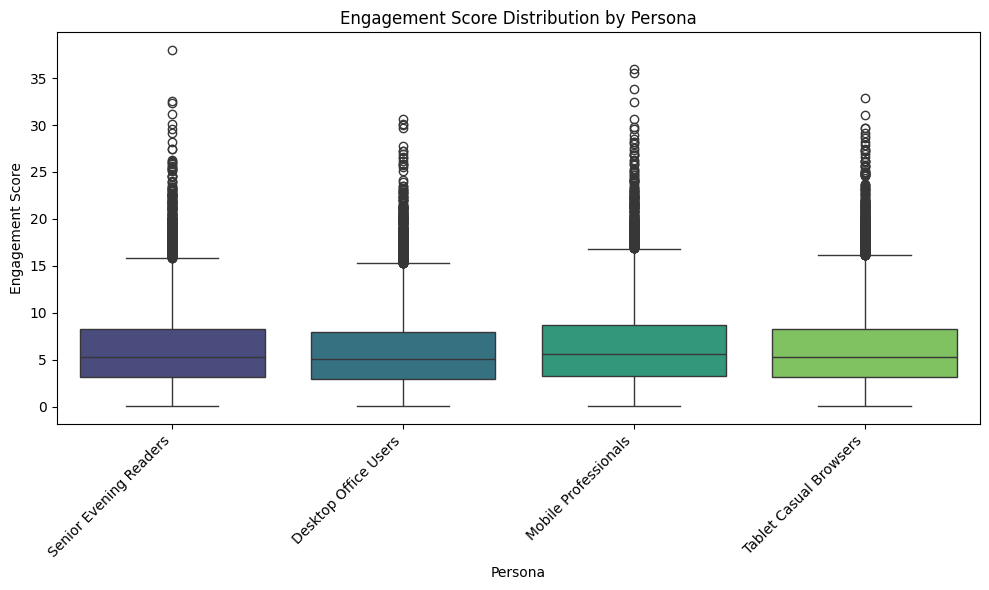

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='persona', y='engagement_score', data=df, hue='persona', palette='viridis', legend=False)
plt.title('Engagement Score Distribution by Persona')
plt.xlabel('Persona')
plt.ylabel('Engagement Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("outputs/engagement_by_persona_boxplot.png")
plt.show()